# SimCLR Tiny

# Architecture

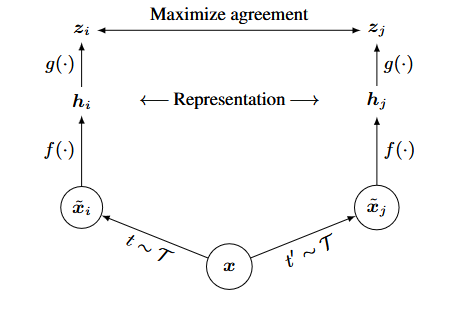

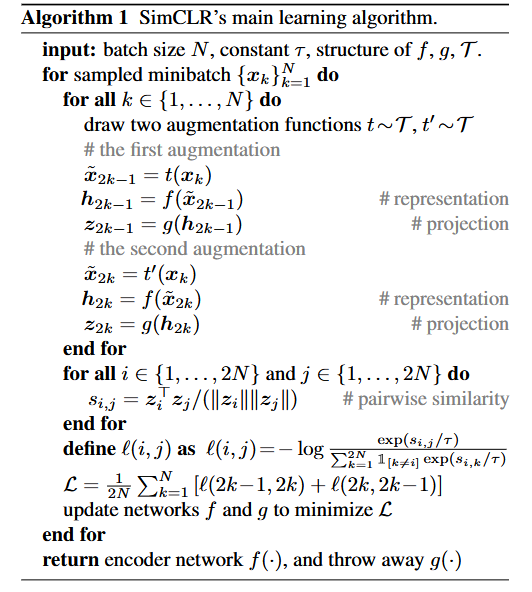

# NT-Xent loss (SimCLR)

For each image $k \in \{1, \dots, N\}$ in the batch, the two augmented views have indices $2k-1$ and $2k$. We use the loss on both directions of the positive pair and average over all $2N$ views:

$$
\mathcal{L}_{\text{NT-Xent}}
= \frac{1}{2N} \sum_{k=1}^{N} \Big[\, \ell(2k-1,\, 2k) + \ell(2k,\, 2k-1) \,\Big]
$$

Replacing $\ell(i,j)$ by its expression (softmax cross-entropy with temperature $\tau$):

$$
\mathcal{L}_{\text{NT-Xent}}
= \frac{1}{2N} \sum_{k=1}^{N} \left[
- \log \frac{\exp\!\big(\mathrm{sim}(z_{2k-1}, z_{2k})/\tau\big)}
{\displaystyle\sum_{m=1}^{2N} \mathbb{1}_{[m \neq 2k-1]}\, \exp\!\big(\mathrm{sim}(z_{2k-1}, z_{m})/\tau\big)}
\; - \;
\log \frac{\exp\!\big(\mathrm{sim}(z_{2k}, z_{2k-1})/\tau\big)}
{\displaystyle\sum_{m=1}^{2N} \mathbb{1}_{[m \neq 2k]}\, \exp\!\big(\mathrm{sim}(z_{2k}, z_{m})/\tau\big)}
\right]
$$

Replacing the cosine similarity by the $\ell_2$-normalized dot product $\mathrm{sim}(u, v) = \dfrac{u^\top v}{\lVert u \rVert \, \lVert v \rVert}$:

$$
\mathcal{L}_{\text{NT-Xent}}
= \frac{1}{2N} \sum_{k=1}^{N} \left[
- \log \frac{\exp\!\Big(\dfrac{z_{2k-1}^\top z_{2k}}{\tau\, \lVert z_{2k-1} \rVert\, \lVert z_{2k} \rVert}\Big)}
{\displaystyle\sum_{m=1}^{2N} \mathbb{1}_{[m \neq 2k-1]}\, \exp\!\Big(\dfrac{z_{2k-1}^\top z_{m}}{\tau\, \lVert z_{2k-1} \rVert\, \lVert z_{m} \rVert}\Big)}
\; - \;
\log \frac{\exp\!\Big(\dfrac{z_{2k}^\top z_{2k-1}}{\tau\, \lVert z_{2k} \rVert\, \lVert z_{2k-1} \rVert}\Big)}
{\displaystyle\sum_{m=1}^{2N} \mathbb{1}_{[m \neq 2k]}\, \exp\!\Big(\dfrac{z_{2k}^\top z_{m}}{\tau\, \lVert z_{2k} \rVert\, \lVert z_{m} \rVert}\Big)}
\right]
$$

where $z_i = g(f(\tilde{x}_i))$ is the projection of view $i$, $\tau$ is the temperature, and $\mathbb{1}_{[m \neq i]}$ excludes the anchor from its own denominator.

## Architecture of $f$ and $g$ in SimCLR

**Encoder $f$ : a ViT-Tiny backbone.** The input image is split into $4\times4$ patches (64 patches of dimension 48), linearly projected to $d_{\text{model}}=128$, prepended with a learnable `[CLS]` token and added to learnable positional embeddings. The sequence then goes through a pre-norm Transformer encoder of **6 layers** (4 heads, feed-forward dim 512, GELU), followed by a final LayerNorm. The representation is the `[CLS]` token:

$$h = f(\tilde{x}) \in \mathbb{R}^{128}$$

This is the **same ViT-Tiny backbone** shared across all methods (supervised ViT, MAE, CPC), which is what makes the benchmark a fair comparison.

**Projection head $g$ : a small MLP.** The representation $h$ is mapped to the space where the contrastive loss is applied by a two-layer MLP with a non-linearity:

$$z = g(h) = W^{(2)}\,\sigma\!\big(\text{BN}(W^{(1)} h)\big), \qquad z \leftarrow \frac{z}{\lVert z \rVert_2}$$

with $W^{(1)}: 128 \to 256$, ReLU activation $\sigma$, and $W^{(2)}: 256 \to 128$. The output $z$ is $\ell_2$-normalized so that the dot product in the NT-Xent loss is a cosine similarity.

**Important : $g$ is discarded after pre-training.** The NT-Xent loss is computed on $z$ (after $g$), but all downstream evaluation (linear probe and fine-tuning) uses $h$ (the encoder output, before $g$). The projection head is thrown away, because $g$ learns to be invariant to the augmentations and discards information (e.g. color, orientation) that is useful for downstream classification.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import math
import os

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "DATA"))
CKPT_DIR = "./checkpoints/6_SIMCLR"
os.makedirs(CKPT_DIR, exist_ok=True)

torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device = {device}")

device = cuda


---
# 0. Dataset

**STL-10 unlabeled** (100k images) for self-supervised pre-training; **CIFAR-10** (50k train / 10k test) for downstream evaluation (linear probe + full fine-tune).

### Data augmentations

In SimCLR the augmentations **define the contrastive task**: each image is passed twice through 'ssl_aug` to produce two random views that form a positive pair.

| Figure 4 | Operator | In the code |
|---|---|---|
| crop and resize | random crop (20-100%) then resize to 32x32 | `RandomResizedCrop(32, scale=(0.2, 1.0))` |
| horizontal flip | left-right mirror | `RandomHorizontalFlip(p=0.5)` |
| color jitter | random brightness / contrast / saturation / hue | `RandomApply([ColorJitter(0.4,0.4,0.4,0.1)], p=0.8)` |
| color drop | convert to grayscale | `RandomGrayscale(p=0.2)` |

In [2]:
BATCH_SIZE = 128
IMG_SIZE   = 32
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)


class TwoViews:
    def __init__(self, transform):
        self.transform = transform
    def __call__(self, x):
        return self.transform(x), self.transform(x)


color_jitter = transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
ssl_aug = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
train_probe_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

pretrain_set = torchvision.datasets.STL10(root=DATA_DIR, split='unlabeled', download=True,
                                           transform=TwoViews(ssl_aug))
probe_train  = torchvision.datasets.CIFAR10(root=DATA_DIR, train=True,  download=True, transform=train_probe_tf)
probe_test   = torchvision.datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_tf)

pretrain_loader     = DataLoader(pretrain_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, drop_last=True)
probe_train_loader  = DataLoader(probe_train,  batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
probe_test_loader   = DataLoader(probe_test,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sample_img, _ = probe_train[0]
CHANNELS, H, W = sample_img.shape
NUM_CLASSES    = len(probe_train.classes)
print(f"pretrain {len(pretrain_set)} | probe train {len(probe_train)} | probe test {len(probe_test)}")

pretrain 100000 | probe train 50000 | probe test 10000


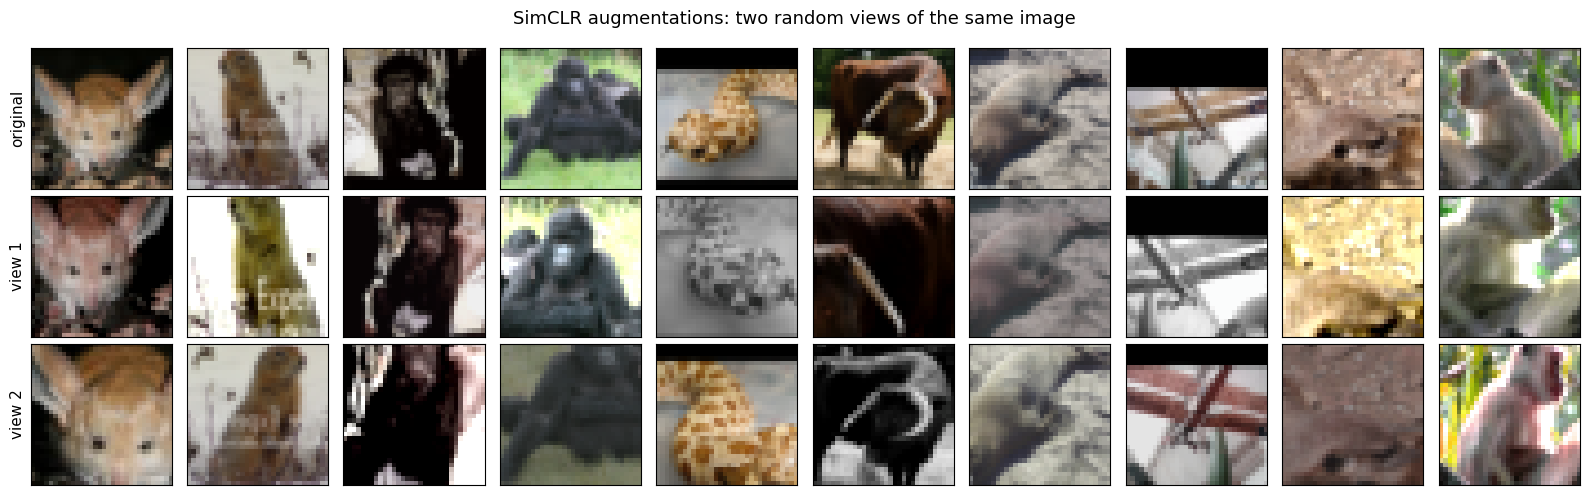

In [3]:
def unnormalize(img):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (img * s + m).clamp(0, 1)

display_tf = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

from PIL import Image
indices = torch.randint(0, len(pretrain_set), (10,))
fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for i, idx in enumerate(indices):
    raw = pretrain_set.data[idx]
    orig = display_tf(Image.fromarray(raw.transpose(1, 2, 0)))
    (v1, v2), _ = pretrain_set[idx]
    for r, v in [(0, orig), (1, v1), (2, v2)]:
        axes[r, i].imshow(unnormalize(v).permute(1, 2, 0).numpy())
        axes[r, i].set_xticks([]); axes[r, i].set_yticks([])
axes[0, 0].set_ylabel('original', fontsize=11)
axes[1, 0].set_ylabel('view 1',   fontsize=11)
axes[2, 0].set_ylabel('view 2',   fontsize=11)
plt.suptitle('SimCLR augmentations: two random views of the same image', fontsize=13)
plt.tight_layout(); plt.show()

---
# 1. Model & hyperparameters

Shared **ViT-Tiny** encoder $f$ (outputs the 128-d `[CLS]` feature $h$) followed by a 2-layer MLP
projection head $g$. The detailed description of $f$ and $g$ is at the top of the notebook.

In [4]:
PATCH_SIZE  = 4
GRID_SIZE   = IMG_SIZE // PATCH_SIZE
N_PATCHES   = GRID_SIZE ** 2
PATCH_DIM   = PATCH_SIZE ** 2 * CHANNELS

D_MODEL    = 128
NUM_HEADS  = 4
NUM_LAYERS = 6
D_FF       = 4 * D_MODEL
DROPOUT    = 0.1

PRETRAIN_EPOCHS = 20
PROBE_EPOCHS    = 60
FT_EPOCHS       = 60

PROJ_DIM = 128
TEMPERATURE = 0.5

In [5]:
def patchify(images, patch_size):
    B, C, H, W = images.shape
    P = patch_size
    x = images.reshape(B, C, H // P, P, W // P, P)
    x = x.permute(0, 2, 4, 3, 5, 1)
    x = x.reshape(B, (H // P) * (W // P), P * P * C)
    return x

In [6]:
class ViTEncoder(nn.Module):
   
    def __init__(self, img_size=IMG_SIZE, patch_size=PATCH_SIZE, channels=CHANNELS,d_model=D_MODEL, num_heads=NUM_HEADS, num_layers=NUM_LAYERS,d_ff=D_FF, dropout=DROPOUT):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2
        patch_dim = patch_size ** 2 * channels
        self.patch_size = patch_size

        self.projection    = nn.Linear(patch_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.02)
        self.dropout       = nn.Dropout(dropout)

        block = nn.TransformerEncoderLayer(d_model=d_model, nhead=num_heads, dim_feedforward=d_ff,dropout=dropout, activation="gelu", batch_first=True, norm_first=True,)
        self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, images):
        x = patchify(images, self.patch_size)
        x = self.projection(x) + self.pos_embedding
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.norm(x)
        return x.mean(dim=1)   #x(B, d_model)

In [7]:
class ProjectionHead(nn.Module):
    def __init__(self, in_dim=D_MODEL, hidden=D_MODEL*2, out_dim=PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(inplace=True), nn.Linear(hidden, out_dim))
        
    def forward(self, h): 
        return self.net(h)


class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = ViTEncoder()
        self.proj    = ProjectionHead()
    def forward(self, x):
        h = self.encoder(x) #h(B,d_model)
        z = F.normalize(self.proj(h), dim=-1) #z(B,proj_dim)
        return h, z


def nt_xent(z1, z2, tau=TEMPERATURE): #z(B,proj_dim)
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0) #z(2B,proj_dim)
    sim = (z @ z.T) / tau #(2B,2B)
    sim = sim.masked_fill(torch.eye(2*B, device=z.device, dtype=torch.bool), float('-inf'))
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, labels)


simclr = SimCLR().to(device)
print(f"params : {sum(p.numel() for p in simclr.parameters()):,}")

C:\Users\hugop\AppData\Local\Temp\ipykernel_7420\2752086745.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)


params : 1,270,784


---
# 2. Pre-training on STL-10

Train $f$ and $g$ with the NT-Xent loss for a fixed budget of 20 epochs (no early stopping: the
pre-training loss is not a reliable proxy for feature quality, and a fixed budget keeps the
benchmark fair across methods).

In [8]:
optimizer = torch.optim.AdamW(simclr.parameters(), lr=3e-4, weight_decay=1e-4)
pretrain_losses = []
for epoch in range(1, PRETRAIN_EPOCHS + 1):
    simclr.train()
    total, n = 0.0, 0
    for (v1, v2), _ in pretrain_loader:
        v1, v2 = v1.to(device), v2.to(device)
        _, z1 = simclr(v1); _, z2 = simclr(v2)
        loss = nt_xent(z1, z2)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total += loss.item() * v1.size(0); n += v1.size(0)
    avg = total / n
    pretrain_losses.append(avg)
    print(f"pretrain {epoch:2d}/{PRETRAIN_EPOCHS} | loss {avg:.4f}")
    torch.save({'epoch': epoch, 'model': simclr.state_dict(), 'losses': pretrain_losses},
               os.path.join(CKPT_DIR, 'simclr_pretrain.pt'))

pretrain  1/20 | loss 4.4720
pretrain  2/20 | loss 4.2862
pretrain  3/20 | loss 4.2249
pretrain  4/20 | loss 4.1904
pretrain  5/20 | loss 4.1641
pretrain  6/20 | loss 4.1434
pretrain  7/20 | loss 4.1293
pretrain  8/20 | loss 4.1152
pretrain  9/20 | loss 4.1039
pretrain 10/20 | loss 4.0948
pretrain 11/20 | loss 4.0871
pretrain 12/20 | loss 4.0795
pretrain 13/20 | loss 4.0729
pretrain 14/20 | loss 4.0657
pretrain 15/20 | loss 4.0623
pretrain 16/20 | loss 4.0551
pretrain 17/20 | loss 4.0524
pretrain 18/20 | loss 4.0473
pretrain 19/20 | loss 4.0446
pretrain 20/20 | loss 4.0424


## Curves

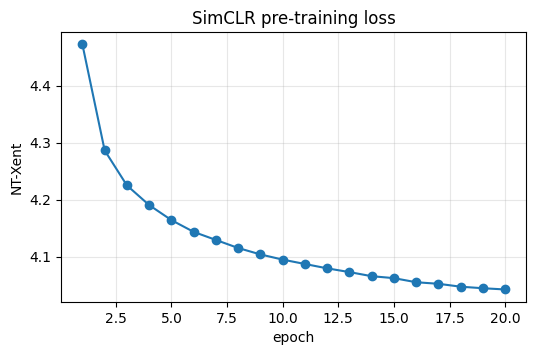

In [9]:
plt.figure(figsize=(6, 3.5))
plt.plot(range(1, len(pretrain_losses) + 1), pretrain_losses, marker='o')
plt.title('SimCLR pre-training loss'); plt.xlabel('epoch'); plt.ylabel('NT-Xent')
plt.grid(True, alpha=0.3); plt.show()

---
# 3. Encoder for probe / fine-tune

Reload the best pre-trained model and expose its encoder. Downstream tasks use the encoder output $h$ ; the projection head $g$ is **discarded**. We also define the training helpers.

In [10]:
def build_eval_encoder():
    m = SimCLR().to(device)
    ckpt = torch.load(os.path.join(CKPT_DIR, 'simclr_pretrain.pt'), map_location=device)
    m.load_state_dict(ckpt['model'])
    return m.encoder

In [11]:
def slope_per_epoch(values, window=5):
    if len(values) < 2:
        return float('inf')
    w = min(window, len(values))
    y = np.array(values[-w:]); x = np.arange(w)
    return float(np.polyfit(x, y, 1)[0])


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total

---
# 4. Linear probe on CIFAR-10

Freeze the encoder, train only a linear classifier head on the frozen feature $h$.

In [12]:
class LinearProbe(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(D_MODEL, num_classes)
        for p in self.encoder.parameters():
            p.requires_grad = False

    def forward(self, x):
        with torch.no_grad():
            h = self.encoder(x)
        return self.head(h)

In [13]:
probe = LinearProbe(build_eval_encoder(), NUM_CLASSES).to(device)
print(f"trainable : {sum(p.numel() for p in probe.head.parameters()):,}")

trainable : 1,290


C:\Users\hugop\AppData\Local\Temp\ipykernel_7420\2752086745.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)


In [14]:
PROBE_LR = 1e-3

optimizer = torch.optim.AdamW(probe.head.parameters(), lr=PROBE_LR, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc = 0.0

for epoch in range(1, PROBE_EPOCHS + 1):
    probe.train()
    probe.encoder.eval()
    tr_loss, tr_acc = train_one_epoch(probe, probe_train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(probe, probe_test_loader, criterion)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{PROBE_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({'epoch': epoch, 'model': probe.state_dict(),
                    'test_accs': test_accs, 'train_accs': train_accs,
                    'test_losses': test_losses, 'train_losses': train_losses},
                   os.path.join(CKPT_DIR, 'simclr_probe_best.pt'))

    best_epoch = test_accs.index(max(test_accs))
    if (len(test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print()
print(f"best test acc : {max(test_accs)*100:.2f}%")
print(f"converged at  : epoch {test_accs.index(max(test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in test_accs]):.3f} %/epoch")

epoch  1/60 | train 1.4356 51.2% | test 1.1987 56.2%
epoch  2/60 | train 1.1939 57.5% | test 1.1411 58.6%
epoch  3/60 | train 1.1542 58.8% | test 1.1132 59.7%
epoch  4/60 | train 1.1358 59.5% | test 1.0976 60.4%
epoch  5/60 | train 1.1179 60.2% | test 1.0907 60.5%
epoch  6/60 | train 1.1098 60.3% | test 1.0842 60.8%
epoch  7/60 | train 1.1010 60.6% | test 1.0738 61.3%
epoch  8/60 | train 1.0941 61.0% | test 1.0703 61.5%
epoch  9/60 | train 1.0902 61.1% | test 1.0564 62.0%
epoch 10/60 | train 1.0836 61.2% | test 1.0508 62.1%
epoch 11/60 | train 1.0816 61.5% | test 1.0488 62.4%
epoch 12/60 | train 1.0766 61.5% | test 1.0472 62.4%
epoch 13/60 | train 1.0723 62.0% | test 1.0369 63.0%
epoch 14/60 | train 1.0712 61.8% | test 1.0453 62.6%
epoch 15/60 | train 1.0648 62.0% | test 1.0357 62.9%
epoch 16/60 | train 1.0643 62.3% | test 1.0332 63.1%
epoch 17/60 | train 1.0622 62.2% | test 1.0339 62.9%
epoch 18/60 | train 1.0607 62.2% | test 1.0243 63.6%
epoch 19/60 | train 1.0578 62.3% | test 1.0225

## Curves

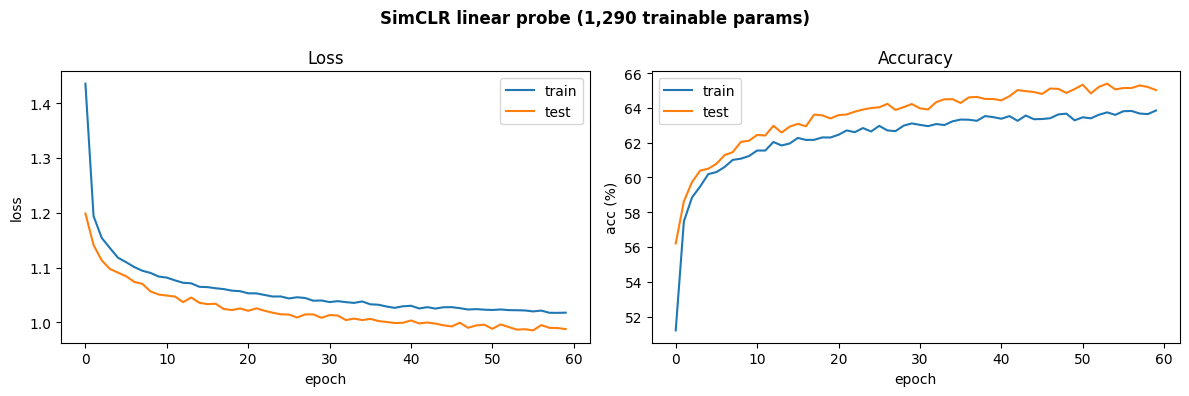

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train'); ax1.plot(test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in train_accs], label='train'); ax2.plot([a*100 for a in test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'SimCLR linear probe ({sum(p.numel() for p in probe.head.parameters()):,} trainable params)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set.

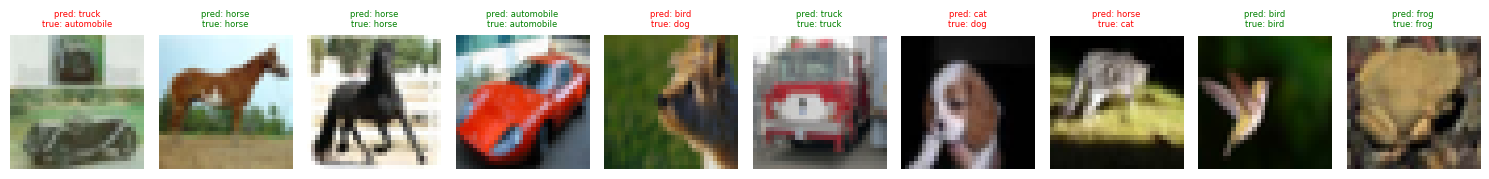

In [16]:
probe.eval()
classes = probe_test.classes
indices = torch.randint(0, len(probe_test), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = probe_test[idx]
    with torch.no_grad():
        logits = probe(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

---
# 5. Full fine-tune on CIFAR-10

Unfreeze the encoder, train everything end-to-end with a small learning rate.

In [17]:
class FullFineTune(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.head    = nn.Linear(D_MODEL, num_classes)

    def forward(self, x):
        h = self.encoder(x)
        return self.head(h)

In [18]:
ft = FullFineTune(build_eval_encoder(), NUM_CLASSES).to(device)
print(f"trainable : {sum(p.numel() for p in ft.parameters()):,}")

trainable : 1,205,642


C:\Users\hugop\AppData\Local\Temp\ipykernel_7420\2752086745.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(block, num_layers=num_layers)


In [19]:
FT_LR = 1e-4

optimizer = torch.optim.AdamW(ft.parameters(), lr=FT_LR, weight_decay=0.05)
criterion = nn.CrossEntropyLoss()

PATIENCE = 8
train_losses, test_losses = [], []
train_accs,   test_accs   = [], []
best_acc = 0.0

for epoch in range(1, FT_EPOCHS + 1):
    ft.train()
    tr_loss, tr_acc = train_one_epoch(ft, probe_train_loader, optimizer, criterion)
    te_loss, te_acc = evaluate(ft, probe_test_loader, criterion)
    train_losses.append(tr_loss); test_losses.append(te_loss)
    train_accs.append(tr_acc);   test_accs.append(te_acc)
    print(f"epoch {epoch:2d}/{FT_EPOCHS} | train {tr_loss:.4f} {tr_acc*100:.1f}% | test {te_loss:.4f} {te_acc*100:.1f}%")

    if te_acc > best_acc:
        best_acc = te_acc
        torch.save({'epoch': epoch, 'model': ft.state_dict(),
                    'test_accs': test_accs, 'train_accs': train_accs,
                    'test_losses': test_losses, 'train_losses': train_losses},
                   os.path.join(CKPT_DIR, 'simclr_ft_best.pt'))

    best_epoch = test_accs.index(max(test_accs))
    if (len(test_accs) - 1 - best_epoch) >= PATIENCE:
        print(f"  early stop : converged (no improvement for {PATIENCE} epochs)")
        break

print()
print(f"best test acc : {max(test_accs)*100:.2f}%")
print(f"converged at  : epoch {test_accs.index(max(test_accs))+1}")
print(f"final slope   : {slope_per_epoch([a*100 for a in test_accs]):.3f} %/epoch")

epoch  1/60 | train 1.2969 55.4% | test 0.9874 64.3%
epoch  2/60 | train 0.9367 67.1% | test 0.8352 70.2%
epoch  3/60 | train 0.8428 70.4% | test 0.7784 72.8%
epoch  4/60 | train 0.7869 72.3% | test 0.7308 74.5%
epoch  5/60 | train 0.7517 73.5% | test 0.6960 75.7%
epoch  6/60 | train 0.7195 74.6% | test 0.6745 76.4%
epoch  7/60 | train 0.6967 75.4% | test 0.6581 76.9%
epoch  8/60 | train 0.6745 76.5% | test 0.6442 77.8%
epoch  9/60 | train 0.6599 76.8% | test 0.6620 77.3%
epoch 10/60 | train 0.6384 77.3% | test 0.6290 78.1%
epoch 11/60 | train 0.6259 77.9% | test 0.6027 79.5%
epoch 12/60 | train 0.6183 78.1% | test 0.6206 78.5%
epoch 13/60 | train 0.6035 78.6% | test 0.6199 78.7%
epoch 14/60 | train 0.5907 79.1% | test 0.5910 79.6%
epoch 15/60 | train 0.5800 79.5% | test 0.5720 80.3%
epoch 16/60 | train 0.5724 79.7% | test 0.5698 80.6%
epoch 17/60 | train 0.5581 80.2% | test 0.5848 80.2%
epoch 18/60 | train 0.5494 80.7% | test 0.5619 80.9%
epoch 19/60 | train 0.5392 81.0% | test 0.5862

## Curves

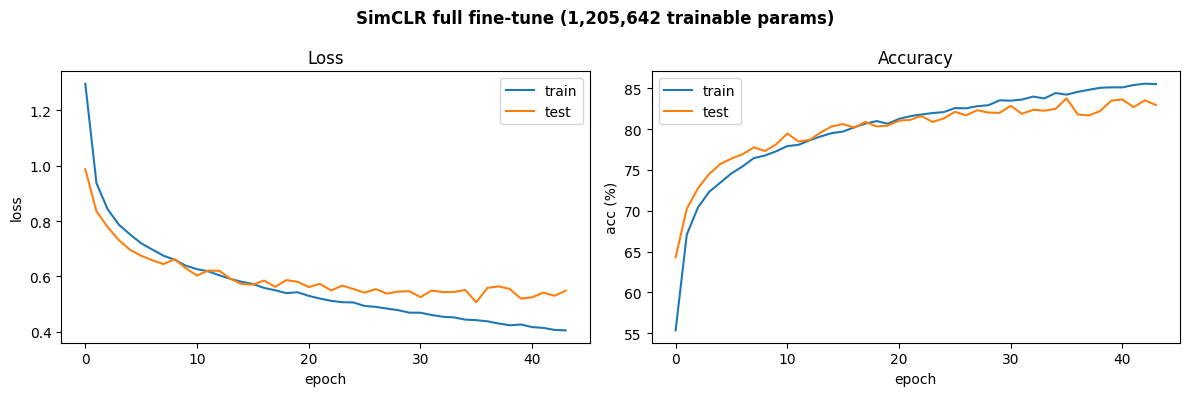

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='train'); ax1.plot(test_losses, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.legend(); ax1.set_title('Loss')
ax2.plot([a*100 for a in train_accs], label='train'); ax2.plot([a*100 for a in test_accs], label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('acc (%)'); ax2.legend(); ax2.set_title('Accuracy')
plt.suptitle(f'SimCLR full fine-tune ({sum(p.numel() for p in ft.parameters()):,} trainable params)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Results

Plot 10 random predictions from the test set.

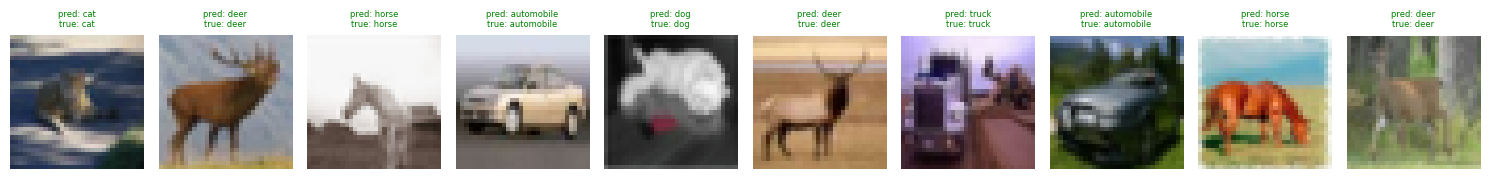

In [21]:
ft.eval()
classes = probe_test.classes
indices = torch.randint(0, len(probe_test), (10,))

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, idx in enumerate(indices):
    img, true_label = probe_test[idx]
    with torch.no_grad():
        logits = ft(img.unsqueeze(0).to(device))
        pred   = logits.argmax(dim=1).item()
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).cpu().numpy())
    color = 'green' if pred == true_label else 'red'
    axes[i].set_title(f"pred: {classes[pred]}\ntrue: {classes[true_label]}",
                       fontsize=6, color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()